In [101]:
!find /content -name "*ETAS-Toolkit*"


/content/ETAS-Toolkit-main (1).zip
/content/ETAS-Toolkit-main
/content/ETAS-Toolkit-main/ETAS-Toolkit-main


In [68]:
!unzip -q "/content/ETAS-Toolkit-main (1).zip" -d "/content/ETAS-Toolkit-main"


replace /content/ETAS-Toolkit-main/ETAS-Toolkit-main/.gitignore? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [102]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find the two files
for root, dirs, files in os.walk("/content"):
    for f in files:
        if f in ["sc-catalog.csv", "usgs_sc_same_region.csv"]:
            print(os.path.join(root, f))

/content/sc-catalog.csv
/content/ETAS-Toolkit-main/ETAS-Toolkit-main/usgs_sc_same_region.csv


In [103]:
import pandas as pd
csv_path = "/content/sc-catalog.csv"
df_csv = pd.read_csv(csv_path)
df_csv.head()

,SCSN Catalog Search Results from SCEDC doi:10.7909/C3WD3xH1
0,<PRE>
1,#YYY/MM/DD HH:mm:SS.ss ET GT MAG M LAT ...
2,2000/01/01 03:58:39.50 eq l 3.04 l 34.80100...
3,2000/01/01 06:08:31.15 eq l 2.64 l 34.37167...
4,2000/01/02 17:58:32.82 eq l 3.14 l 34.30900...


In [71]:
import pandas as pd
csv_path = "/content/ETAS-Toolkit-main/ETAS-Toolkit-main/usgs_sc_same_region.csv"
df_csv = pd.read_csv(csv_path)
df_csv.head()

,time,magnitude,latitude,longitude,depth,event_id
0,2000-01-01 03:58:39.500000+00:00,3.04,34.801000,-116.287000,5.414,ci9132027
1,2000-01-01 06:08:31.150000+00:00,2.64,34.371667,-116.137333,2.946,ci9132039
2,2000-01-02 17:58:32.820000+00:00,3.14,34.309000,-116.072000,0.801,ci9132273
3,2000-01-03 00:40:56.990000+00:00,2.55,32.433000,-115.331000,5.998,ci9132305
4,2000-01-03 03:07:57.530000+00:00,2.81,34.379000,-116.459000,4.360,ci9132315


In [72]:
import pandas as pd
import numpy as np

print("SCSN shape:", scsn.shape)
print("USGS shape:", usgs.shape)

print("\nSCSN columns:")
print(scsn.columns.tolist())

print("\nUSGS columns:")
print(usgs.columns.tolist())

SCSN shape: (9417, 6)
USGS shape: (10347, 6)

SCSN columns:
['time', 'magnitude', 'latitude', 'longitude', 'depth', 'event_id']

USGS columns:
['time', 'magnitude', 'latitude', 'longitude', 'depth', 'event_id']


**Fix SCSN CSV**

In [74]:
# Inspect the raw SCSN file
with open("sc-catalog.txt", "r", errors="ignore") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

for i, line in enumerate(lines[:30]):
    print(i, repr(line))

Total lines: 9423
0 'SCSN Catalog Search Results from SCEDC doi:10.7909/C3WD3xH1\n'
1 '<PRE>\n'
2 '#YYY/MM/DD HH:mm:SS.ss ET GT MAG  M    LAT       LON      DEPTH Q  EVID      NPH NGRM\n'
3 '2000/01/01 03:58:39.50 eq  l 3.04 l   34.80100 -116.28700   5.4 A  9132027   37 1239\n'
4 '2000/01/01 06:08:31.15 eq  l 2.64 l   34.37167 -116.13733   2.9 A  9132039   56 1228\n'
5 '2000/01/02 17:58:32.82 eq  l 3.14 l   34.30900 -116.07200   0.8 A  9132273   64 1237\n'
6 '2000/01/03 00:40:56.99 eq  l 2.55 l   32.43300 -115.33100   6.0 C  9132305   13   73\n'
7 '2000/01/03 03:07:57.52 eq  l 2.81 c   34.37900 -116.45900   4.4 C  9132315   42 1023\n'
8 '2000/01/03 03:48:18.91 eq  l 2.95 l   34.53483 -116.04317   2.0 A  9132330   42 1256\n'
9 '2000/01/03 21:13:46.09 eq  l 2.54 l   34.64683 -116.32233   4.2 B  9132411   31  260\n'
10 '2000/01/03 21:35:06.87 eq  l 2.60 l   34.37600 -116.44600   1.4 A  9132417   39  271\n'
11 '2000/01/03 21:59:31.78 eq  l 3.49 l   34.10100 -117.00800   2.3 A  9132433   94

In [75]:
# Show lines containing likely earthquake data
for i, line in enumerate(lines):
    if "</PRE>" in line or "DATE" in line.upper() or "TIME" in line.upper():
        print(i, repr(line[:300]))

9422 '</PRE>\n'


**Parse SCSN correctly**

In [76]:
import pandas as pd
import re

records = []

with open("sc-catalog.txt", "r", errors="ignore") as f:
    for line in f:
        line = line.strip()

        # Keep only earthquake data rows beginning with YYYY/MM/DD
        if re.match(r"^\d{4}/\d{2}/\d{2}", line):
            parts = line.split()

            # Corrected indices based on raw file inspection:
            # 0:Date, 1:Time, 2:ET, 3:GT, 4:MAG, 5:M, 6:LAT, 7:LON, 8:DEPTH, 9:Q, 10:EVID
            records.append({
                "time": parts[0] + " " + parts[1],
                "magnitude": float(parts[4]),
                "latitude": float(parts[6]),
                "longitude": float(parts[7]),
                "depth": float(parts[8]),
                "event_id": parts[10]
            })

scsn = pd.DataFrame(records)

# Convert time
scsn["time"] = pd.to_datetime(scsn["time"], format="%Y/%m/%d %H:%M:%S.%f")

print("SCSN shape:", scsn.shape)
display(scsn.head())
display(scsn.tail())

print("\nSCSN columns:")
print(scsn.columns.tolist())

SCSN shape: (9417, 6)


,time,magnitude,latitude,longitude,depth,event_id
0,2000-01-01 03:58:39.500,3.04,34.80100,-116.28700,5.4,9132027
1,2000-01-01 06:08:31.150,2.64,34.37167,-116.13733,2.9,9132039
2,2000-01-02 17:58:32.820,3.14,34.30900,-116.07200,0.8,9132273
3,2000-01-03 00:40:56.990,2.55,32.43300,-115.33100,6.0,9132305
4,2000-01-03 03:07:57.520,2.81,34.37900,-116.45900,4.4,9132315


,time,magnitude,latitude,longitude,depth,event_id
9412,2010-12-29 20:12:43.150,2.75,32.11250,-115.25650,5.5,10864485
9413,2010-12-30 14:12:52.870,2.50,32.04800,-115.13100,13.4,10864709
9414,2010-12-30 16:02:42.170,2.52,32.27783,-115.35950,11.9,10864725
9415,2010-12-30 17:37:20.820,3.80,32.99167,-116.35467,4.4,10864749
9416,2010-12-31 17:59:32.590,3.07,32.24267,-115.38450,-0.0,10865061



SCSN columns:
['time', 'magnitude', 'latitude', 'longitude', 'depth', 'event_id']


**standardize USGS**

In [77]:
import pandas as pd

# Use ISO8601 format to handle mixed precision (with/without fractional seconds)
usgs["time"] = pd.to_datetime(usgs["time"], format='ISO8601', utc=True)

# Make SCSN timezone-aware as UTC
scsn["time"] = scsn["time"].dt.tz_localize("UTC")

print("SCSN period:")
print(scsn["time"].min(), "to", scsn["time"].max())

print("\nUSGS period:")
print(usgs["time"].min(), "to", usgs["time"].max())

print("\nSCSN magnitude:")
print(scsn["magnitude"].min(), "to", scsn["magnitude"].max())

print("\nUSGS magnitude:")
print(usgs["magnitude"].min(), "to", usgs["magnitude"].max())

SCSN period:
2000-01-01 03:58:39.500000+00:00 to 2010-12-31 17:59:32.590000+00:00

USGS period:
2000-01-01 03:58:39.500000+00:00 to 2010-12-31 17:59:32.590000+00:00

SCSN magnitude:
2.5 to 7.2

USGS magnitude:
2.5 to 7.2


**Find the common period**

In [78]:
# Make sure both time columns are UTC
usgs["time"] = pd.to_datetime(usgs["time"], utc=True)
scsn["time"] = pd.to_datetime(scsn["time"], utc=True)

# Common overlapping period
start = max(scsn["time"].min(), usgs["time"].min())
end   = min(scsn["time"].max(), usgs["time"].max())

print("SCSN period :", scsn["time"].min(), "→", scsn["time"].max())
print("USGS period :", usgs["time"].min(), "→", usgs["time"].max())
print("\nCOMMON PERIOD:")
print(start, "→", end)

# Restrict both to exactly the same period
scsn_common = scsn[(scsn["time"] >= start) & (scsn["time"] <= end)].copy()
usgs_common = usgs[(usgs["time"] >= start) & (usgs["time"] <= end)].copy()

print("\nEvents in common period:")
print("SCSN:", len(scsn_common))
print("USGS:", len(usgs_common))

SCSN period : 2000-01-01 03:58:39.500000+00:00 → 2010-12-31 17:59:32.590000+00:00
USGS period : 2000-01-01 03:58:39.500000+00:00 → 2010-12-31 17:59:32.590000+00:00

COMMON PERIOD:
2000-01-01 03:58:39.500000+00:00 → 2010-12-31 17:59:32.590000+00:00

Events in common period:
SCSN: 9417
USGS: 10347


**comparison table**

In [79]:
summary = pd.DataFrame({
    "SCSN": [
        len(scsn_common),
        scsn_common["magnitude"].min(),
        scsn_common["magnitude"].max(),
        scsn_common["latitude"].min(),
        scsn_common["latitude"].max(),
        scsn_common["longitude"].min(),
        scsn_common["longitude"].max()
    ],
    "USGS": [
        len(usgs_common),
        usgs_common["magnitude"].min(),
        usgs_common["magnitude"].max(),
        usgs_common["latitude"].min(),
        usgs_common["latitude"].max(),
        usgs_common["longitude"].min(),
        usgs_common["longitude"].max()
    ]
}, index=[
    "Number of events",
    "Minimum magnitude",
    "Maximum magnitude",
    "Minimum latitude",
    "Maximum latitude",
    "Minimum longitude",
    "Maximum longitude"
])

display(summary.round(3))

,SCSN,USGS
Number of events,9417.000,10347.000
Minimum magnitude,2.500,2.500
Maximum magnitude,7.200,7.200
Minimum latitude,32.000,32.001
Maximum latitude,36.985,36.985
Minimum longitude,-120.925,-120.924
Maximum longitude,-114.357,-114.374


**Figure:1 - Spatial comparision**

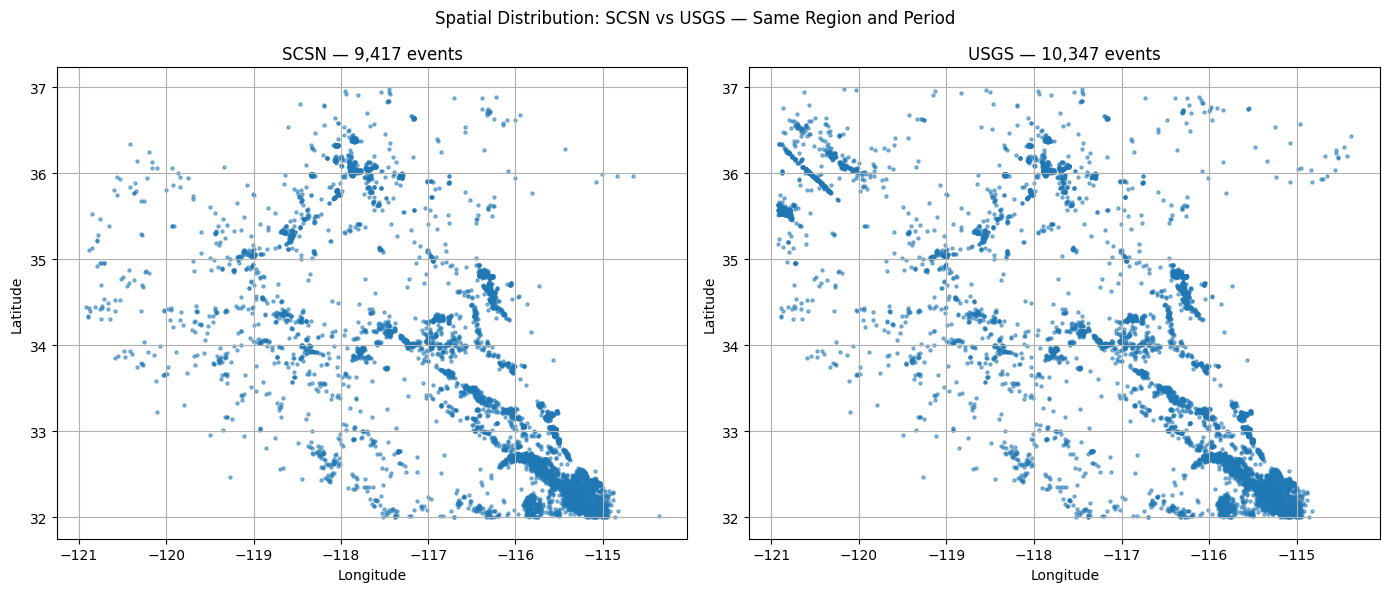

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    scsn_common["longitude"],
    scsn_common["latitude"],
    s=5, alpha=0.5
)
axes[0].set_title(f"SCSN — {len(scsn_common):,} events")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(True)

axes[1].scatter(
    usgs_common["longitude"],
    usgs_common["latitude"],
    s=5, alpha=0.5
)
axes[1].set_title(f"USGS — {len(usgs_common):,} events")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(True)

plt.suptitle("Spatial Distribution: SCSN vs USGS — Same Region and Period")
plt.tight_layout()
plt.show()

**Figure 2: magnitude distribution**

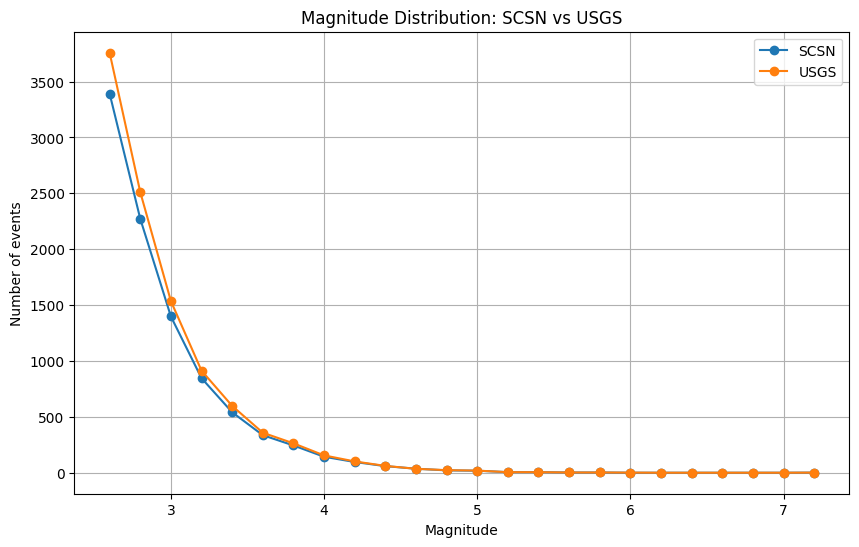

In [81]:
# Common magnitude bins
bins = np.arange(
    min(scsn_common["magnitude"].min(), usgs_common["magnitude"].min()),
    max(scsn_common["magnitude"].max(), usgs_common["magnitude"].max()) + 0.2,
    0.2
)

scsn_hist, _ = np.histogram(scsn_common["magnitude"], bins=bins)
usgs_hist, _ = np.histogram(usgs_common["magnitude"], bins=bins)

centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(10, 6))
plt.plot(centers, scsn_hist, marker="o", label="SCSN")
plt.plot(centers, usgs_hist, marker="o", label="USGS")

plt.xlabel("Magnitude")
plt.ylabel("Number of events")
plt.title("Magnitude Distribution: SCSN vs USGS")
plt.legend()
plt.grid(True)
plt.show()

**Match common events**

In [82]:
from scipy.spatial import cKDTree

# Work on copies
s = scsn_common.reset_index(drop=True).copy()
u = usgs_common.reset_index(drop=True).copy()

# Convert lat/lon to approximate km coordinates
lat0 = np.mean(pd.concat([s["latitude"], u["latitude"]]))

km_per_deg_lat = 111.32
km_per_deg_lon = 111.32 * np.cos(np.radians(lat0))

s_x = s["longitude"].values * km_per_deg_lon
s_y = s["latitude"].values * km_per_deg_lat

u_x = u["longitude"].values * km_per_deg_lon
u_y = u["latitude"].values * km_per_deg_lat

# Spatial search within ~15 km
tree = cKDTree(np.column_stack([u_x, u_y]))
dist, idx = tree.query(
    np.column_stack([s_x, s_y]),
    distance_upper_bound=15
)

# Build candidate matches
matches = []

for i in range(len(s)):
    if np.isinf(dist[i]):
        continue

    j = idx[i]

    time_diff = abs(
        (s.loc[i, "time"] - u.loc[j, "time"]).total_seconds()
    )

    # Require origin times within 60 seconds
    if time_diff <= 60:
        matches.append({
            "scsn_index": i,
            "usgs_index": j,
            "scsn_time": s.loc[i, "time"],
            "usgs_time": u.loc[j, "time"],
            "scsn_mag": s.loc[i, "magnitude"],
            "usgs_mag": u.loc[j, "magnitude"],
            "scsn_lat": s.loc[i, "latitude"],
            "usgs_lat": u.loc[j, "latitude"],
            "scsn_lon": s.loc[i, "longitude"],
            "usgs_lon": u.loc[j, "longitude"],
            "scsn_depth": s.loc[i, "depth"],
            "usgs_depth": u.loc[j, "depth"],
            "time_diff_sec": time_diff,
            "horizontal_distance_km": dist[i]
        })

matched = pd.DataFrame(matches)

print("Matched events:", len(matched))
print("SCSN events:", len(s))
print("USGS events:", len(u))

print(
    f"\nSCSN matched: {len(matched)/len(s)*100:.1f}%"
)
print(
    f"USGS matched: {len(matched)/len(u)*100:.1f}%"
)

display(matched.head())

Matched events: 9353
SCSN events: 9417
USGS events: 10347

SCSN matched: 99.3%
USGS matched: 90.4%


,scsn_index,usgs_index,scsn_time,usgs_time,scsn_mag,usgs_mag,scsn_lat,usgs_lat,scsn_lon,usgs_lon,scsn_depth,usgs_depth,time_diff_sec,horizontal_distance_km
0,0,0,2000-01-01 03:58:39.500000+00:00,2000-01-01 03:58:39.500000+00:00,3.04,3.04,34.80100,34.801000,-116.28700,-116.287000,5.4,5.414,0.00,0.000000
1,1,1,2000-01-01 06:08:31.150000+00:00,2000-01-01 06:08:31.150000+00:00,2.64,2.64,34.37167,34.371667,-116.13733,-116.137333,2.9,2.946,0.00,0.000479
2,2,2,2000-01-02 17:58:32.820000+00:00,2000-01-02 17:58:32.820000+00:00,3.14,3.14,34.30900,34.309000,-116.07200,-116.072000,0.8,0.801,0.00,0.000000
3,3,3,2000-01-03 00:40:56.990000+00:00,2000-01-03 00:40:56.990000+00:00,2.55,2.55,32.43300,32.433000,-115.33100,-115.331000,6.0,5.998,0.00,0.000000
4,4,4,2000-01-03 03:07:57.520000+00:00,2000-01-03 03:07:57.530000+00:00,2.81,2.81,34.37900,34.379000,-116.45900,-116.459000,4.4,4.360,0.01,0.000000


**Validate the event matching**

In [84]:
# Check whether one USGS event was matched to multiple SCSN events
duplicate_usgs = matched["usgs_index"].duplicated().sum()
duplicate_scsn = matched["scsn_index"].duplicated().sum()

print("Duplicate USGS matches:", duplicate_usgs)
print("Duplicate SCSN matches:", duplicate_scsn)

# Number of unique events actually matched
print("Unique USGS events matched:", matched["usgs_index"].nunique())
print("Unique SCSN events matched:", matched["scsn_index"].nunique())

Duplicate USGS matches: 0
Duplicate SCSN matches: 0
Unique USGS events matched: 9353
Unique SCSN events matched: 9353


**inspect the unmatched events**

In [104]:
matched_scsn = set(matched["scsn_index"])
matched_usgs = set(matched["usgs_index"])

unmatched_scsn = s.loc[~s.index.isin(matched_scsn)]
unmatched_usgs = u.loc[~u.index.isin(matched_usgs)]

print("Unmatched SCSN:", len(unmatched_scsn))
print("Unmatched USGS:", len(unmatched_usgs))


Unmatched SCSN: 64
Unmatched USGS: 994


**Figure:3 - Magnitude agreement**

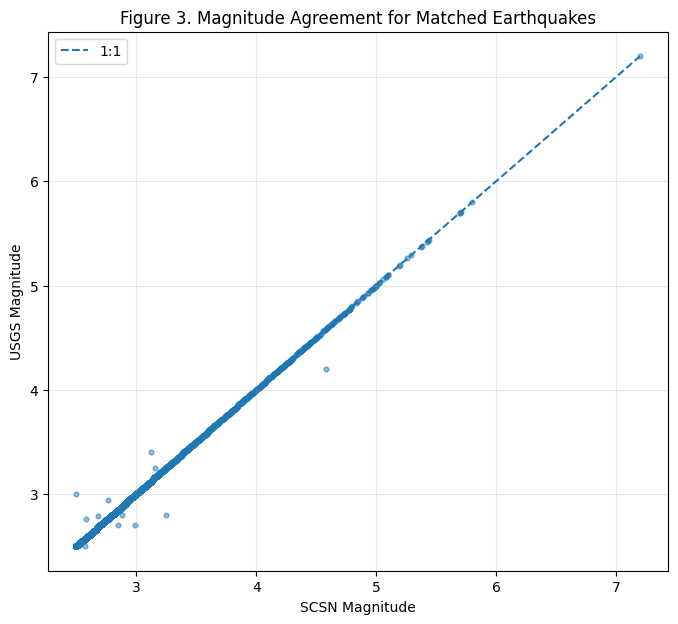

Correlation: 0.9997541170056111
Mean ΔM (USGS − SCSN): -8.553405324494918e-06
Median ΔM: 0.0
RMSE: 0.009693253194339634


In [86]:
plt.figure(figsize=(8, 7))

plt.scatter(
    matched["scsn_mag"],
    matched["usgs_mag"],
    s=12,
    alpha=0.5
)

mmin = min(matched["scsn_mag"].min(), matched["usgs_mag"].min())
mmax = max(matched["scsn_mag"].max(), matched["usgs_mag"].max())

plt.plot([mmin, mmax], [mmin, mmax], "--", label="1:1")

plt.xlabel("SCSN Magnitude")
plt.ylabel("USGS Magnitude")
plt.title("Figure 3. Magnitude Agreement for Matched Earthquakes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Correlation:", matched["scsn_mag"].corr(matched["usgs_mag"]))
print("Mean ΔM (USGS − SCSN):", matched["delta_mag"].mean())
print("Median ΔM:", matched["delta_mag"].median())
print("RMSE:", np.sqrt(np.mean(matched["delta_mag"]**2)))

**Figure 4: Magnitude difference**

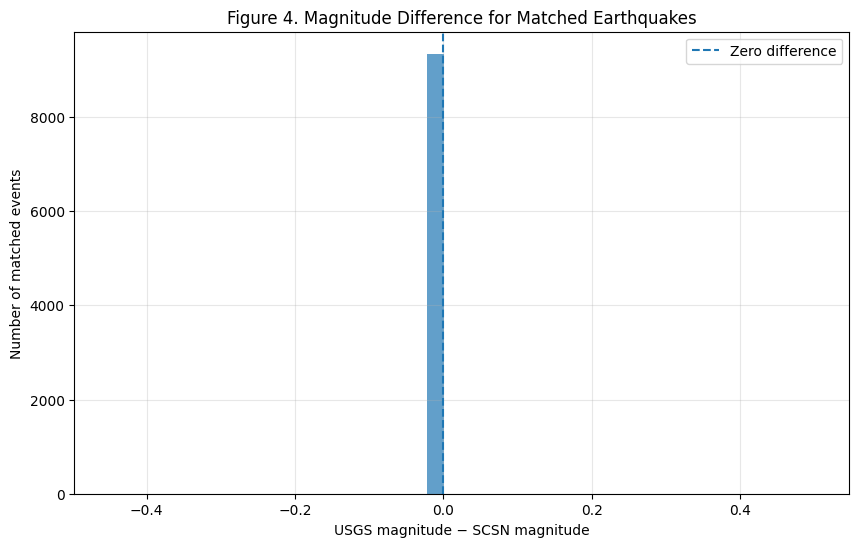

In [87]:
plt.figure(figsize=(10, 6))

plt.hist(
    matched["delta_mag"],
    bins=40,
    alpha=0.7
)

plt.axvline(0, linestyle="--", label="Zero difference")

plt.xlabel("USGS magnitude − SCSN magnitude")
plt.ylabel("Number of matched events")
plt.title("Figure 4. Magnitude Difference for Matched Earthquakes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Figure 5: Location agreement**

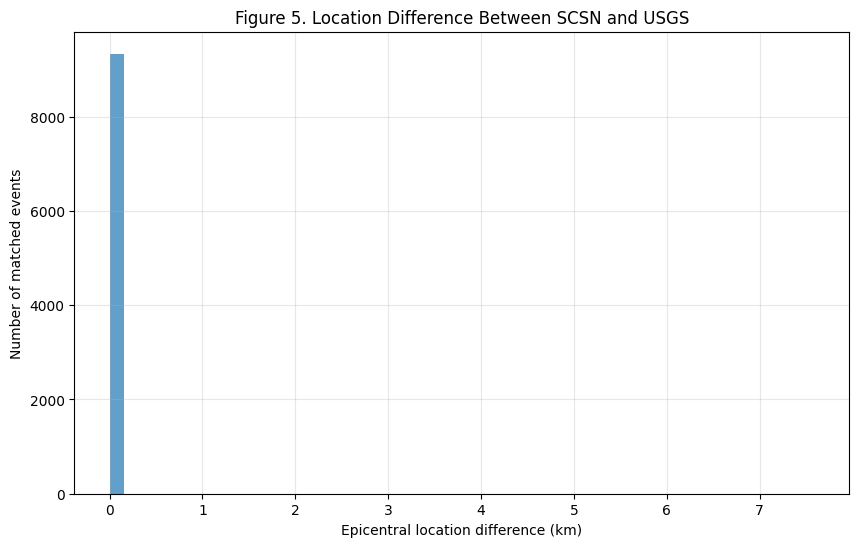

Median location difference: 0.00036735600042447913 km
Mean location difference: 0.006461735064812377 km
90th percentile: 0.0004785410064188833 km


In [88]:
plt.figure(figsize=(10, 6))

plt.hist(
    matched["horizontal_distance_km"],
    bins=50,
    alpha=0.7
)

plt.xlabel("Epicentral location difference (km)")
plt.ylabel("Number of matched events")
plt.title("Figure 5. Location Difference Between SCSN and USGS")
plt.grid(True, alpha=0.3)
plt.show()

print("Median location difference:",
      matched["horizontal_distance_km"].median(), "km")

print("Mean location difference:",
      matched["horizontal_distance_km"].mean(), "km")

print("90th percentile:",
      matched["horizontal_distance_km"].quantile(0.90), "km")

This strongly suggests the two catalogs are likely drawing from very closely related/identical event solutions, rather than being completely independent location determinations. Don't state that as a conclusion yet—we'll support it with the remaining checks.

In [89]:
print("SCSN magnitude column:")
print(scsn_common["magnitude"].describe())

print("\nUSGS columns:")
print(usgs_common.columns.tolist())

print("""
SCSN catalog header identifies the reported magnitude as ML/local magnitude.
The current USGS CSV does not contain a magnitude-type field.
""")

SCSN magnitude column:
count    9417.000000
mean        2.938547
std         0.437252
min         2.500000
25%         2.620000
50%         2.800000
75%         3.110000
max         7.200000
Name: magnitude, dtype: float64

USGS columns:
['time', 'magnitude', 'latitude', 'longitude', 'depth', 'event_id']

SCSN catalog header identifies the reported magnitude as ML/local magnitude.
The current USGS CSV does not contain a magnitude-type field.



**calculate Mc separately**

In [90]:
def calculate_mc_max_curvature(magnitudes, bin_width=0.1):
    mags = np.asarray(magnitudes)

    min_mag = np.floor(mags.min() / bin_width) * bin_width
    max_mag = np.ceil(mags.max() / bin_width) * bin_width

    bins = np.arange(min_mag, max_mag + bin_width, bin_width)
    counts, edges = np.histogram(mags, bins=bins)

    centers = edges[:-1] + bin_width / 2

    mc = centers[np.argmax(counts)]

    return mc, centers, counts


mc_scsn, bins_scsn, counts_scsn = calculate_mc_max_curvature(
    scsn_common["magnitude"]
)

mc_usgs, bins_usgs, counts_usgs = calculate_mc_max_curvature(
    usgs_common["magnitude"]
)

print("SCSN Mc =", mc_scsn)
print("USGS Mc =", mc_usgs)

SCSN Mc = 2.55
USGS Mc = 2.55


**Mc comparision**

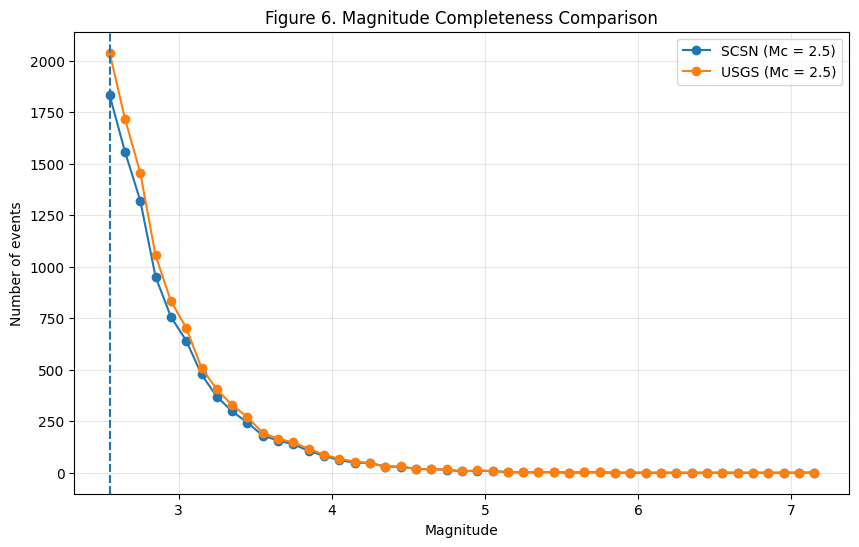

In [91]:
plt.figure(figsize=(10, 6))

plt.plot(
    bins_scsn,
    counts_scsn,
    marker="o",
    label=f"SCSN (Mc = {mc_scsn:.1f})"
)

plt.plot(
    bins_usgs,
    counts_usgs,
    marker="o",
    label=f"USGS (Mc = {mc_usgs:.1f})"
)

plt.axvline(mc_scsn, linestyle="--")
plt.axvline(mc_usgs, linestyle=":")

plt.xlabel("Magnitude")
plt.ylabel("Number of events")
plt.title("Figure 6. Magnitude Completeness Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Gutenberg–Richter comparison**

In [92]:
def b_value_mle(magnitudes, mc, bin_width=0.1):
    mags = np.asarray(magnitudes)
    mags = mags[mags >= mc]

    b = np.log10(np.e) / (
        np.mean(mags) - (mc - bin_width / 2)
    )

    return b, len(mags)


b_scsn, n_scsn_mc = b_value_mle(
    scsn_common["magnitude"], mc_scsn
)

b_usgs, n_usgs_mc = b_value_mle(
    usgs_common["magnitude"], mc_usgs
)

print(f"SCSN: Mc = {mc_scsn:.2f}, b = {b_scsn:.3f}, N = {n_scsn_mc}")
print(f"USGS: Mc = {mc_usgs:.2f}, b = {b_usgs:.3f}, N = {n_usgs_mc}")

SCSN: Mc = 2.55, b = 0.888, N = 8409
USGS: Mc = 2.55, b = 0.897, N = 9229


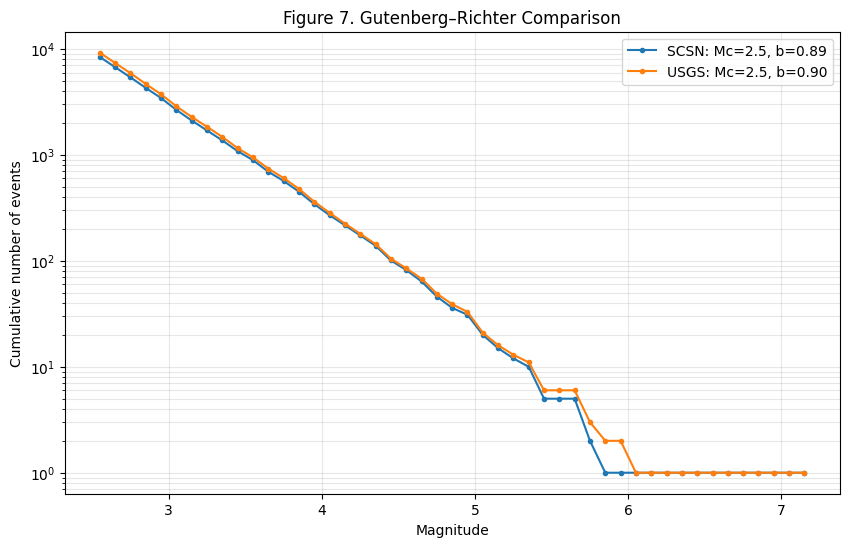

In [93]:
plt.figure(figsize=(10, 6))

for mags, label, mc, b in [
    (scsn_common["magnitude"], "SCSN", mc_scsn, b_scsn),
    (usgs_common["magnitude"], "USGS", mc_usgs, b_usgs)
]:
    m = np.arange(mc, mags.max() + 0.1, 0.1)
    cumulative = np.array([
        np.sum(mags >= x) for x in m
    ])

    mask = cumulative > 0

    plt.semilogy(
        m[mask],
        cumulative[mask],
        marker="o",
        markersize=3,
        label=f"{label}: Mc={mc:.1f}, b={b:.2f}"
    )

plt.xlabel("Magnitude")
plt.ylabel("Cumulative number of events")
plt.title("Figure 7. Gutenberg–Richter Comparison")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

**Temporal rate changes**

In [94]:
scsn_monthly = (
    scsn_common
    .set_index("time")
    .resample("ME")
    .size()
)

usgs_monthly = (
    usgs_common
    .set_index("time")
    .resample("ME")
    .size()
)

monthly = pd.concat(
    [scsn_monthly, usgs_monthly],
    axis=1
)

monthly.columns = ["SCSN", "USGS"]

display(monthly.head())

,SCSN,USGS
time,,
2000-01-31 00:00:00+00:00,68,73
2000-02-29 00:00:00+00:00,65,66
2000-03-31 00:00:00+00:00,75,77
2000-04-30 00:00:00+00:00,67,72
2000-05-31 00:00:00+00:00,101,106


**Raw catalog rate**

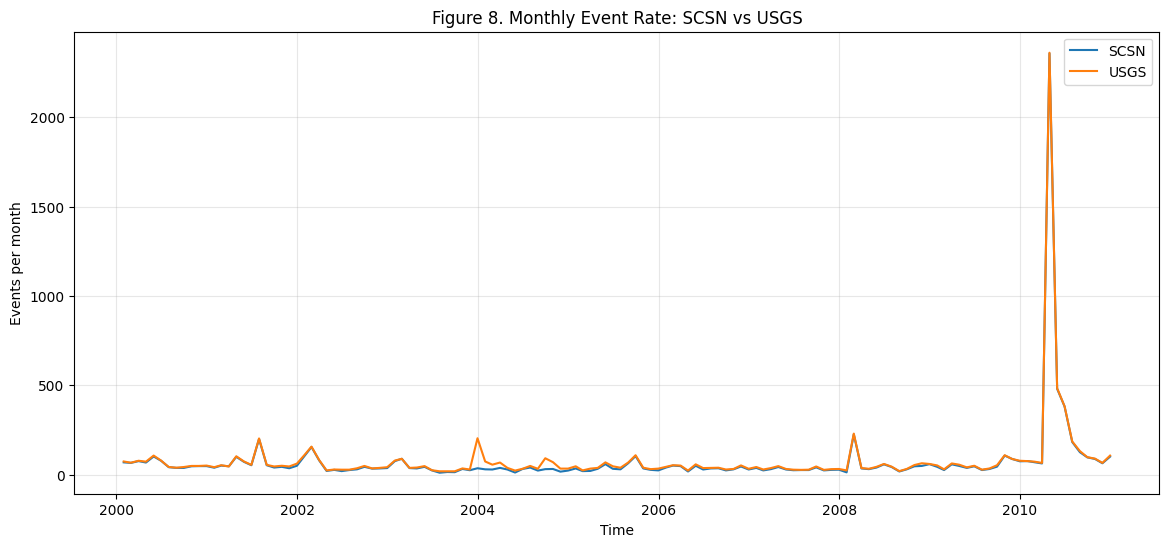

In [95]:
plt.figure(figsize=(14, 6))

plt.plot(monthly.index, monthly["SCSN"], label="SCSN")
plt.plot(monthly.index, monthly["USGS"], label="USGS")

plt.xlabel("Time")
plt.ylabel("Events per month")
plt.title("Figure 8. Monthly Event Rate: SCSN vs USGS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**common Mc threshold**

In [96]:
common_mc = max(mc_scsn, mc_usgs)

print("Common completeness threshold:", common_mc)

Common completeness threshold: 2.55


**earthquake counts above that threshold**

In [97]:
scsn_complete = scsn_common[
    scsn_common["magnitude"] >= common_mc
].copy()

usgs_complete = usgs_common[
    usgs_common["magnitude"] >= common_mc
].copy()

scsn_complete_monthly = (
    scsn_complete
    .set_index("time")
    .resample("ME")
    .size()
)

usgs_complete_monthly = (
    usgs_complete
    .set_index("time")
    .resample("ME")
    .size()
)

complete_monthly = pd.concat(
    [scsn_complete_monthly, usgs_complete_monthly],
    axis=1
)

complete_monthly.columns = ["SCSN", "USGS"]

**Figure 9 — Common-completeness rate**

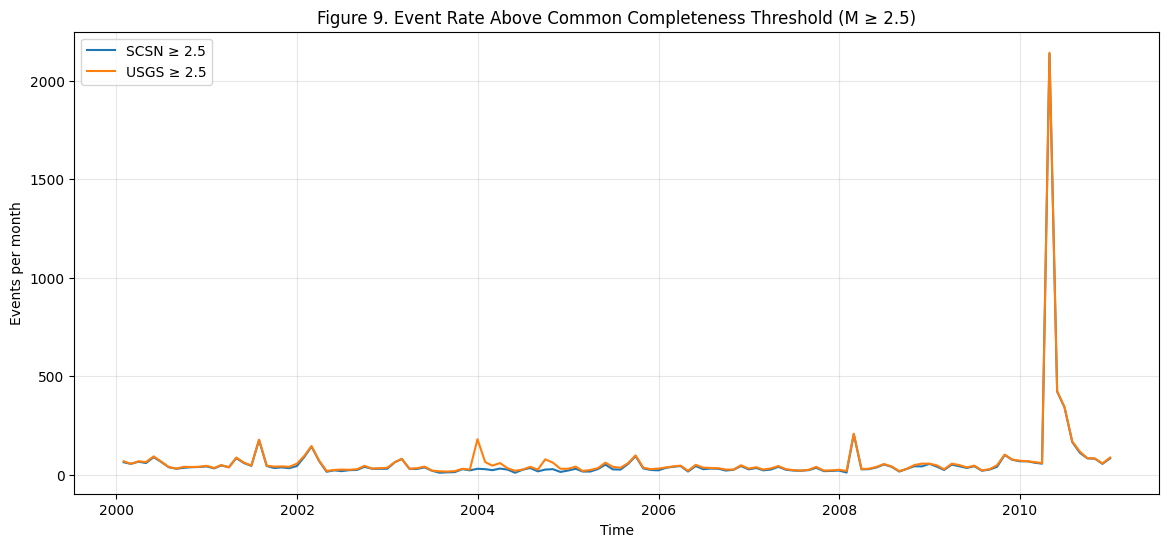

In [98]:
plt.figure(figsize=(14, 6))

plt.plot(
    complete_monthly.index,
    complete_monthly["SCSN"],
    label=f"SCSN ≥ {common_mc:.1f}"
)

plt.plot(
    complete_monthly.index,
    complete_monthly["USGS"],
    label=f"USGS ≥ {common_mc:.1f}"
)

plt.xlabel("Time")
plt.ylabel("Events per month")
plt.title(
    f"Figure 9. Event Rate Above Common Completeness Threshold (M ≥ {common_mc:.1f})"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Quantify temporal agreement**

In [99]:
# Correlation between monthly rates
raw_corr = monthly["SCSN"].corr(monthly["USGS"])
complete_corr = complete_monthly["SCSN"].corr(complete_monthly["USGS"])

print(f"Raw monthly-rate correlation: {raw_corr:.4f}")
print(f"Monthly-rate correlation for M >= 2.6: {complete_corr:.4f}")

# Monthly ratio
monthly_ratio = monthly["USGS"] / monthly["SCSN"].replace(0, np.nan)

print("\nMedian monthly USGS/SCSN ratio:",
      monthly_ratio.median())

print("Mean monthly USGS/SCSN ratio:",
      monthly_ratio.mean())

Raw monthly-rate correlation: 0.9970
Monthly-rate correlation for M >= 2.6: 0.9971

Median monthly USGS/SCSN ratio: 1.0906292749658002
Mean monthly USGS/SCSN ratio: 1.2258128478883974


**Figure 10: Monthly USGS/SCSN reporting ratio**

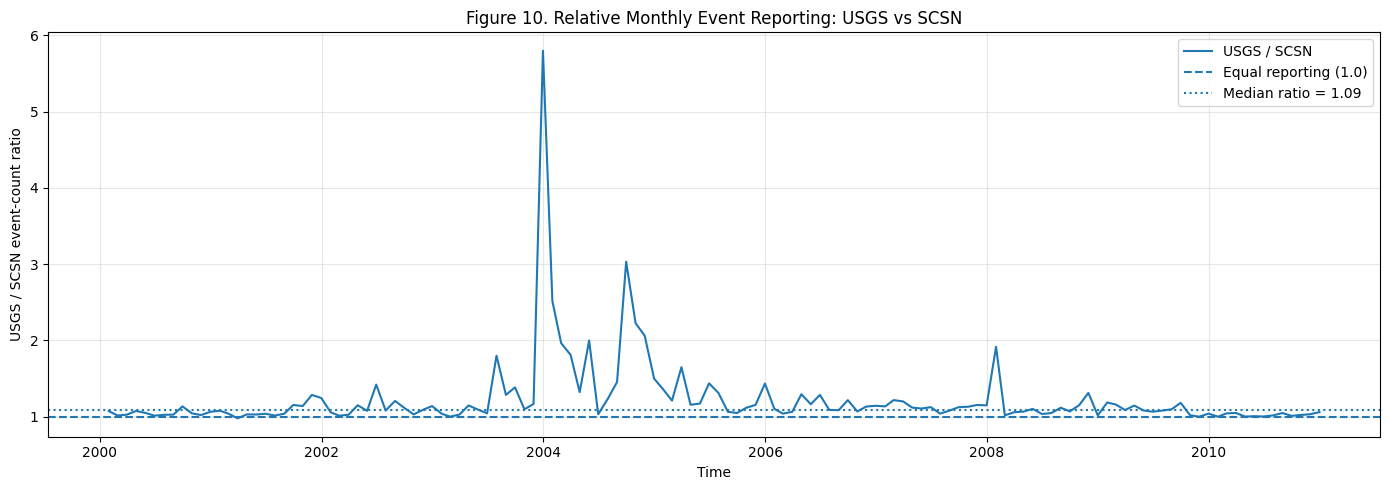

In [100]:
# Monthly reporting ratio
ratio = monthly["USGS"] / monthly["SCSN"].replace(0, np.nan)

plt.figure(figsize=(14, 5))

plt.plot(
    ratio.index,
    ratio.values,
    label="USGS / SCSN"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Equal reporting (1.0)"
)

plt.axhline(
    ratio.median(),
    linestyle=":",
    label=f"Median ratio = {ratio.median():.2f}"
)

plt.xlabel("Time")
plt.ylabel("USGS / SCSN event-count ratio")
plt.title("Figure 10. Relative Monthly Event Reporting: USGS vs SCSN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()